# Exploratory Data Analysis

## Objective

The objective of this analysis is to explore employee data and identify meaningful patterns and trends related to workforce composition, salary, employee status, performance, remote work, departments, and hiring activity.

The analysis focuses on business-oriented questions that can support workforce planning and management decisions.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [21]:
# Load the cleaned dataset

file_path = "../outputs/cleaned_employee_dataset.csv"

df = pd.read_csv(file_path)

df["Join_Date"] = pd.to_datetime(df["Join_Date"])

print("Cleaned dataset loaded successfully.")
print("Shape:", df.shape)

Cleaned dataset loaded successfully.
Shape: (1020, 12)


# 1. Dataset Overview

Before performing detailed analysis, the cleaned dataset is reviewed to understand its structure, employee attributes, and available analytical fields.

The dataset contains 1,020 employee records across 12 columns, covering employee identity, department and region, employment status, joining date, salary, performance, and remote-work information.

This overview provides the foundation for identifying meaningful business questions for further analysis.

In [22]:
# Display the first few records

df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,2021-04-02,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,30.0,Finance-Texas,Active,2020-07-10,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,30.0,Admin-Nevada,Pending,2023-12-07,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,2021-11-27,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,2022-01-05,109324.61,frank.williams@example.com,-1586734256,Poor,False


## 2. Dataset Profile

The following checks provide a basic statistical and structural profile of the employee dataset.

This helps establish the scale of the workforce and understand the distribution of key numerical variables before deeper analysis.

In [23]:
# Basic statistical summary

df.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,1020.0,31.970588,25.0,30.0,30.0,35.0,40.0,5.136901
Join_Date,1020,2022-07-26 12:53:38.823529,2020-01-01 00:00:00,2021-04-12 06:00:00,2022-08-09 12:00:00,2023-10-31 12:00:00,2024-12-29 00:00:00,NaN
Salary,1020.0,85164.299069,50047.32,68811.2325,85547.87,100372.6625,119971.65,19638.38574
Phone,1020.0,-4942252959.221569,-9994973202.0,-7341991816.5,-4943996508.5,-2520390678.75,-3896086.0,2817326049.742002


## 3. Categorical Distribution

Categorical variables are examined to understand the composition of the workforce across employment status, performance categories, and remote-work arrangements.

In [24]:
# Distribution of key categorical variables

print("Employee Status:")
print(df["Status"].value_counts())

print("\nPerformance Score:")
print(df["Performance_Score"].value_counts())

print("\nRemote Work:")
print(df["Remote_Work"].value_counts())

Employee Status:
Status
Pending     356
Active      352
Inactive    312
Name: count, dtype: int64

Performance Score:
Performance_Score
Good         270
Average      267
Excellent    267
Poor         216
Name: count, dtype: int64

Remote Work:
Remote_Work
True     513
False    507
Name: count, dtype: int64


## 4. Workforce Distribution by Department and Region

Understanding how employees are distributed across departments and regions helps identify workforce concentration and organizational structure.

This analysis determines which department-region combinations have the largest employee populations and provides a basis for workforce planning.

In [25]:
# Employee distribution by department and region

department_counts = df["Department_Region"].value_counts()

print("Top 10 Department-Region combinations:")
print(department_counts.head(10))

Top 10 Department-Region combinations:
Department_Region
HR-Florida           41
DevOps-California    35
Sales-Nevada         35
Admin-Nevada         34
Admin-California     34
DevOps-Florida       34
DevOps-New York      33
HR-New York          33
Sales-Florida        33
DevOps-Illinois      33
Name: count, dtype: int64


### Workforce Distribution Visualization

A bar chart is used to compare employee counts across the department-region combinations.

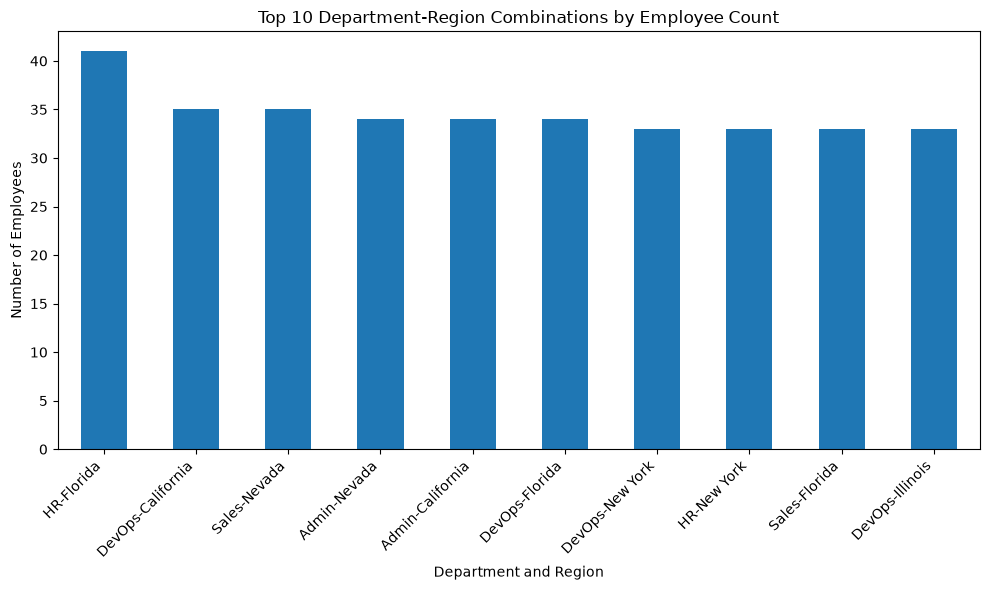

In [26]:
# Visualize the top 10 department-region combinations

top_departments = department_counts.head(10)

plt.figure(figsize=(10, 6))
top_departments.plot(kind="bar")

plt.title("Top 10 Department-Region Combinations by Employee Count")
plt.xlabel("Department and Region")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Salary Analysis

Salary distribution is examined to understand workforce compensation levels and identify differences in salary across departments and employee groups.

This analysis helps provide a basic view of compensation patterns that can support workforce budgeting and compensation planning.

In [27]:
# Basic salary statistics

print("Salary Statistics:")
print(df["Salary"].describe())

print("\nAverage Salary:", round(df["Salary"].mean(), 2))
print("Median Salary:", round(df["Salary"].median(), 2))
print("Minimum Salary:", round(df["Salary"].min(), 2))
print("Maximum Salary:", round(df["Salary"].max(), 2))

Salary Statistics:
count      1020.000000
mean      85164.299069
std       19638.385740
min       50047.320000
25%       68811.232500
50%       85547.870000
75%      100372.662500
max      119971.650000
Name: Salary, dtype: float64

Average Salary: 85164.3
Median Salary: 85547.87
Minimum Salary: 50047.32
Maximum Salary: 119971.65


### Salary Distribution

A histogram is used to visualize how employee salaries are distributed across the workforce.

This helps identify the most common salary ranges and understand the overall compensation pattern.

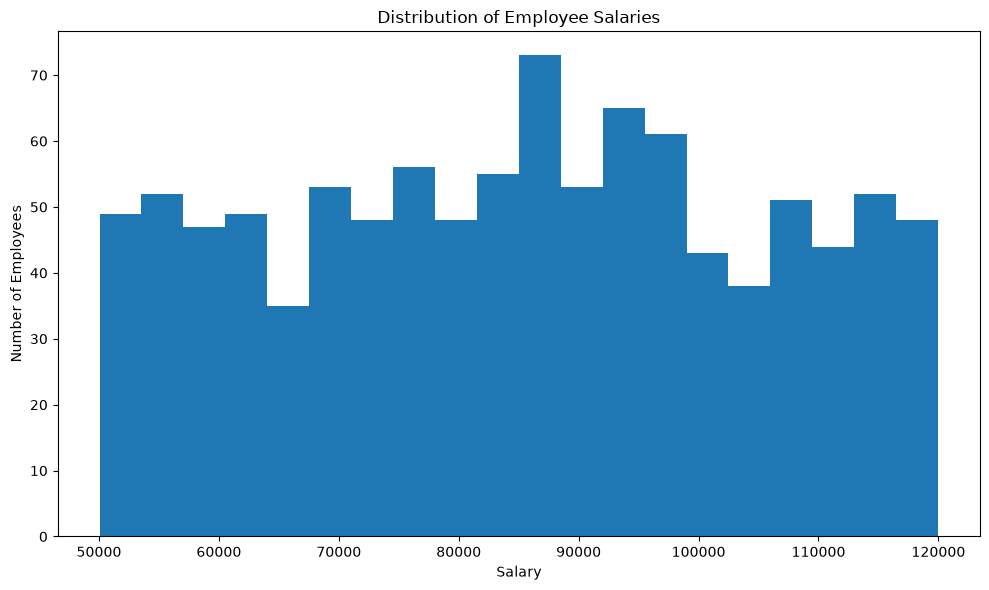

In [28]:
# Visualize salary distribution

plt.figure(figsize=(10, 6))

plt.hist(df["Salary"], bins=20)

plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## 6. Average Salary by Department and Region

Average salary is compared across department-region combinations to identify differences in compensation levels.

This analysis can help management understand compensation patterns across different workforce segments and support budgeting and workforce planning decisions.

In [29]:
# Calculate average salary by department and region

avg_salary_department = (
    df.groupby("Department_Region")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Department-Region combinations by Average Salary:")
print(avg_salary_department.head(10).round(2))


Top 10 Department-Region combinations by Average Salary:
Department_Region
Admin-Illinois        92050.90
Cloud Tech-Florida    91715.49
Sales-Florida         90582.74
DevOps-Nevada         90001.82
Admin-California      89564.11
Finance-New York      89159.34
Sales-California      88533.92
HR-Texas              88007.28
HR-California         87745.02
HR-Illinois           87707.82
Name: Salary, dtype: float64


### Average Salary by Department and Region

A bar chart is used to compare the average salary across the top department-region combinations.

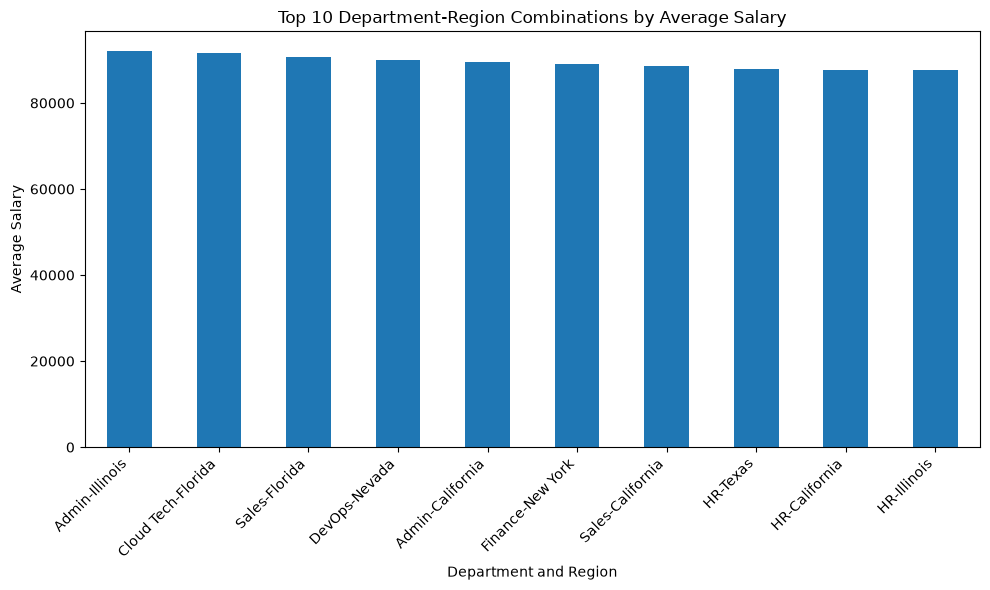

In [30]:
# Visualize the top 10 department-region combinations by average salary

top_salary_departments = avg_salary_department.head(10)

plt.figure(figsize=(10, 6))

top_salary_departments.plot(kind="bar")

plt.title("Top 10 Department-Region Combinations by Average Salary")
plt.xlabel("Department and Region")
plt.ylabel("Average Salary")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 7. Employee Performance Analysis

Employee performance ratings are analyzed to understand the overall performance distribution across the workforce.

This analysis helps management identify performance patterns and supports workforce planning, performance management, and employee development decisions.

In [32]:
# Performance score distribution

print("Performance Score Distribution:")
print(df["Performance_Score"].value_counts().sort_index())

Performance Score Distribution:
Performance_Score
Average      267
Excellent    267
Good         270
Poor         216
Name: count, dtype: int64


In [ ]:
print(df.columns.tolist())

['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Department_Region', 'Status', 'Join_Date', 'Salary', 'Email', 'Phone', 'Performance_Score', 'Remote_Work']


In [ ]:
# Performance score distribution

print("Performance Score Distribution:")
print(df["Performance_Score"].value_counts().sort_index())

Performance Score Distribution:
Performance_Score
Average      267
Excellent    267
Good         270
Poor         216
Name: count, dtype: int64


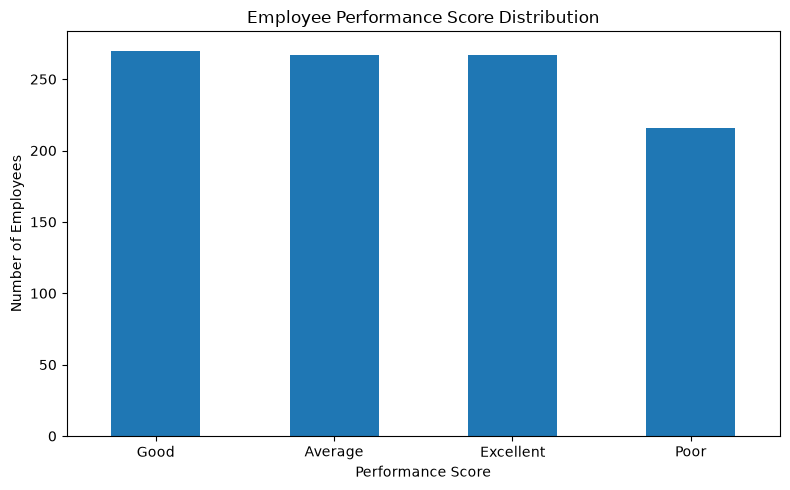

In [ ]:
# Visualize performance score distribution

performance_counts = df["Performance_Score"].value_counts()

plt.figure(figsize=(8, 5))
performance_counts.plot(kind="bar")

plt.title("Employee Performance Score Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Remote Work Analysis

This analysis examines the distribution of employees working remotely versus those working on-site.

Understanding remote work patterns can help management evaluate workforce flexibility, workplace requirements, and office capacity planning.

In [ ]:
# Remote work distribution

print("Remote Work Distribution:")
print(df["Remote_Work"].value_counts())

Remote Work Distribution:
Remote_Work
True     513
False    507
Name: count, dtype: int64


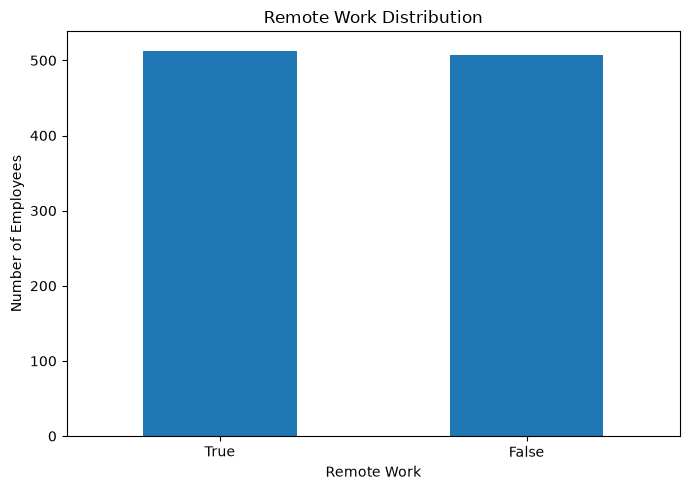

In [ ]:
# Visualize remote work distribution

remote_counts = df["Remote_Work"].value_counts()

plt.figure(figsize=(7, 5))
remote_counts.plot(kind="bar")

plt.title("Remote Work Distribution")
plt.xlabel("Remote Work")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9. Hiring Activity Analysis

This analysis examines employee joining dates to understand hiring patterns over time.

Identifying periods of higher or lower hiring activity can help management understand workforce growth and recruitment trends.

In [ ]:
# Hiring activity by year

df["Join_Year"] = df["Join_Date"].dt.year

hiring_by_year = df["Join_Year"].value_counts().sort_index()

print("Employees Joined by Year:")
print(hiring_by_year)

Employees Joined by Year:
Join_Year
2020    203
2021    189
2022    183
2023    228
2024    217
Name: count, dtype: int64


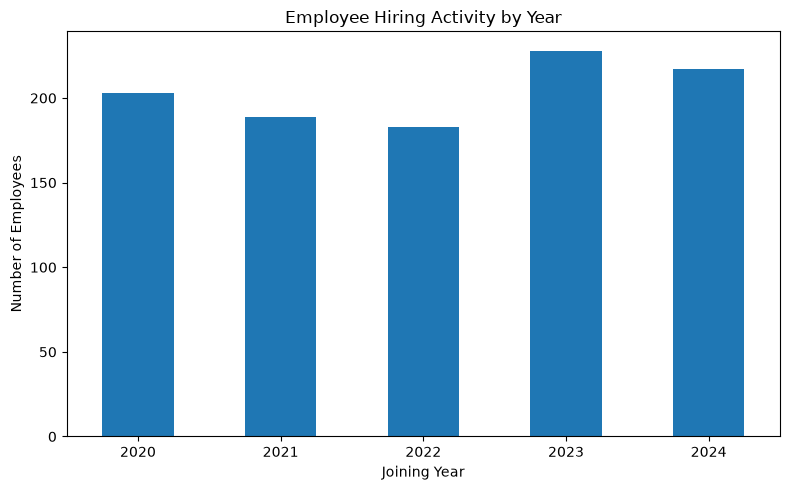

In [ ]:
# Visualize hiring activity by year

plt.figure(figsize=(8, 5))
hiring_by_year.plot(kind="bar")

plt.title("Employee Hiring Activity by Year")
plt.xlabel("Joining Year")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 10. Key Business Insights

- The workforce is almost evenly divided between remote and non-remote employees, indicating a balanced work model.
- Good, Average, and Excellent performance categories have similar employee counts, while the Poor category has fewer employees.
- Hiring activity was highest in 2023 and lowest in 2022, indicating variations in recruitment activity across the years.
- Workforce distribution varies across department-region combinations, highlighting differences in employee concentration.
- Average salary differs across department-region combinations, indicating variations in compensation levels across workforce segments.

These insights can support workforce planning, compensation analysis, recruitment planning, and management decision-making.